In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/Advertising.csv")

In [3]:
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [12]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200.0,100.5000,57.879185,1.0,50.750,100.50,150.250,200.0
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [10]:
df.isna().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [11]:
df.duplicated().sum()

0

<Axes: xlabel='TV', ylabel='Count'>

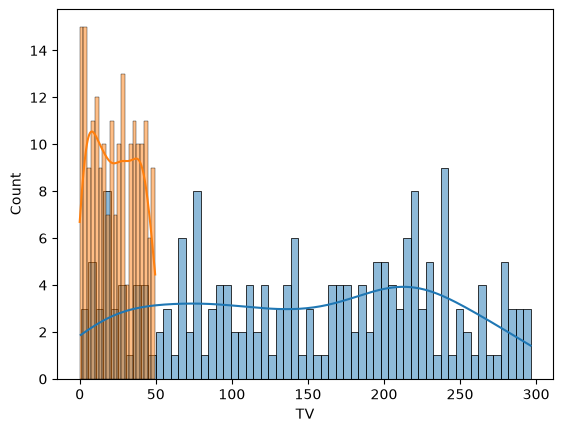

In [63]:
sns.histplot(df,x='TV',bins=60,kde=1)
sns.histplot(df,x='radio',bins=20,kde=1)
#sns.histplot(df,x='newspaper')

<Axes: xlabel='newspaper', ylabel='Count'>

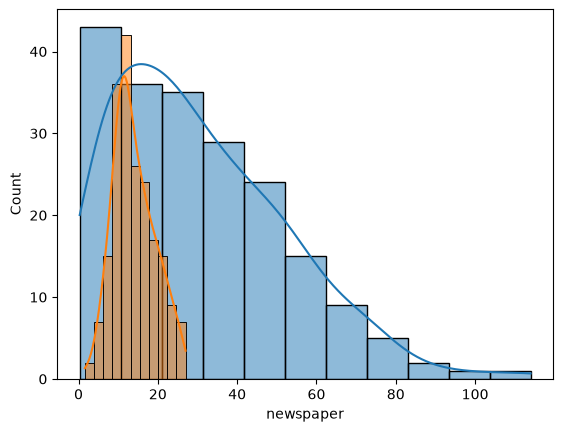

In [55]:
sns.histplot(df,x='newspaper',kde=1)
sns.histplot(df,x='sales',kde=1)


<Axes: xlabel='radio'>

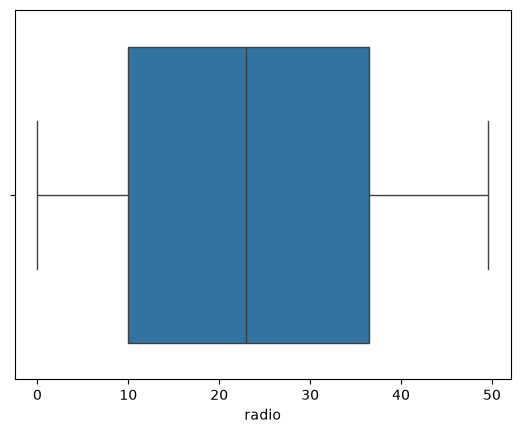

In [41]:
sns.boxplot(data=df,x='radio')

<Axes: xlabel='TV', ylabel='newspaper'>

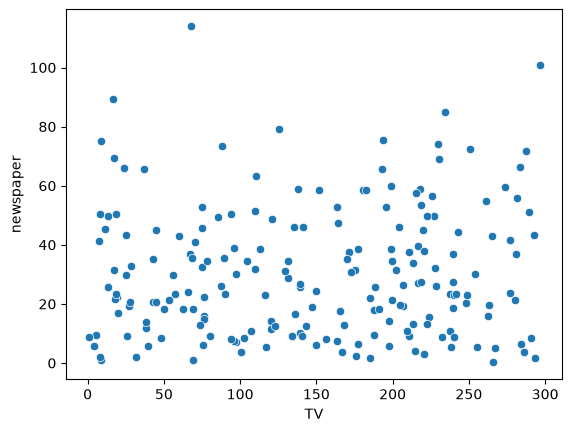

In [42]:
sns.scatterplot(df,x='TV',y='newspaper')

<Axes: xlabel='TV', ylabel='radio'>

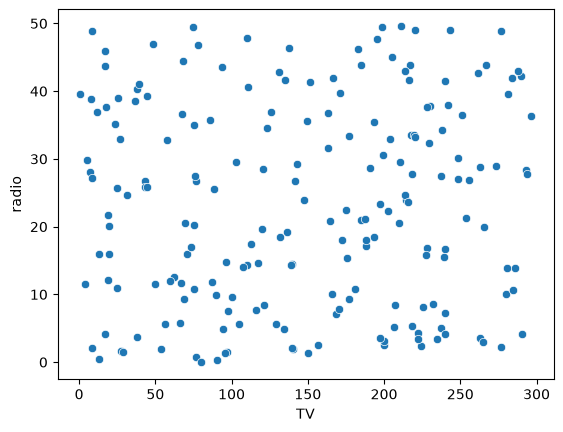

In [43]:
sns.scatterplot(df,x='TV',y='radio')


<Axes: xlabel='radio', ylabel='newspaper'>

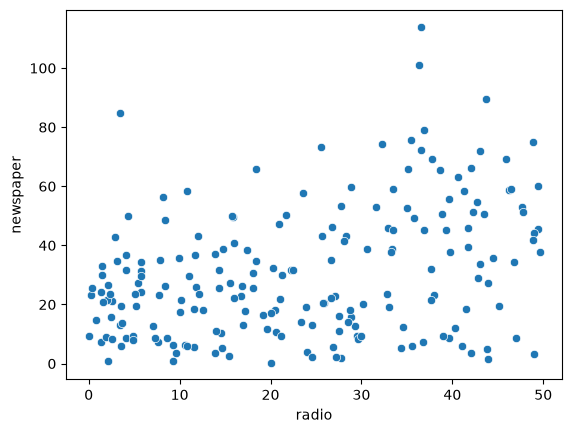

In [44]:
sns.scatterplot(df,x='radio',y='newspaper')


0.7822244248616061

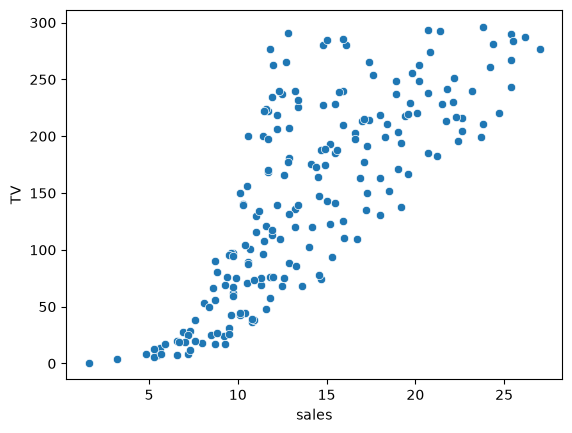

In [48]:
sns.scatterplot(df,x='sales',y='TV')
df['TV'].corr(df['sales'])

<Axes: xlabel='radio', ylabel='sales'>

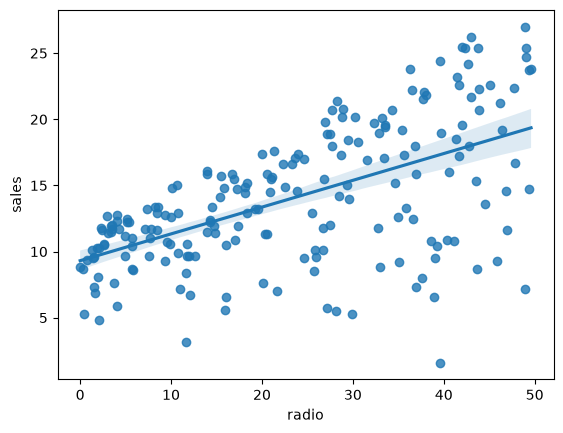

In [78]:
#sns.scatterplot(df,x='radio',y='sales')
df['radio'].corr(df['sales'])
sns.regplot(data=df, x='radio', y='sales')

<Axes: xlabel='sales', ylabel='newspaper'>

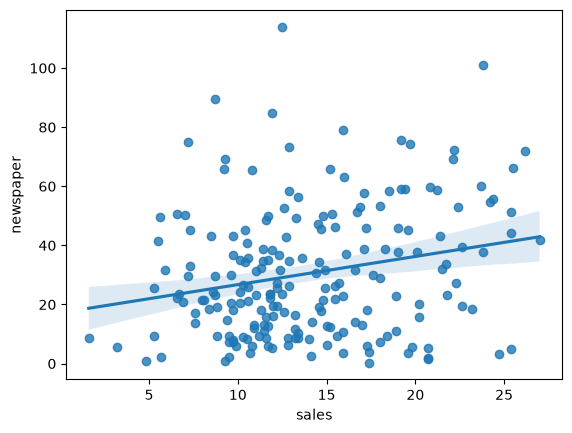

In [73]:
df['newspaper'].corr(df['sales'])
sns.regplot(data=df, x='sales', y='newspaper')

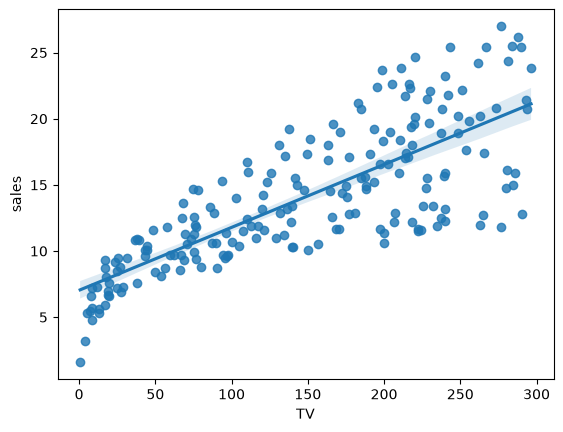

In [79]:
sns.regplot(data=df, x='TV', y='sales')
plt.show()

In [71]:
df[(df['radio']>5) & (df['radio']<30)]

,Unnamed: 0,TV,radio,newspaper,sales
4,5,180.8,10.8,58.4,12.9
7,8,120.2,19.6,11.6,13.2
10,11,66.1,5.8,24.2,8.6
11,12,214.7,24.0,4.0,17.4
13,14,97.5,7.6,7.2,9.7
...,...,...,...,...,...
188,189,286.0,13.9,3.7,15.9
189,190,18.7,12.1,23.4,6.7
191,192,75.5,10.8,6.0,9.9
197,198,177.0,9.3,6.4,12.8


<Axes: xlabel='newspaper'>

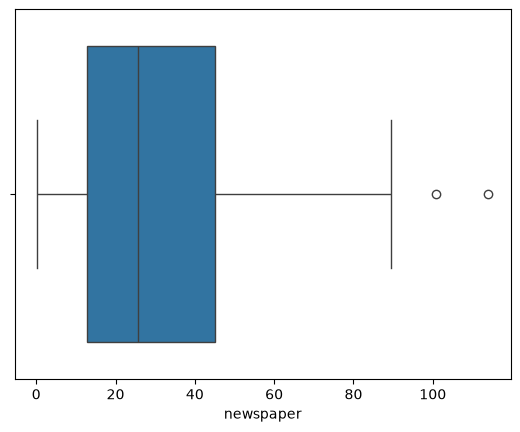

In [84]:
df['newspaper'].skew()
sns.boxplot(data=df, x='newspaper')

In [85]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200.0,100.5000,57.879185,1.0,50.750,100.50,150.250,200.0
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


<Axes: >

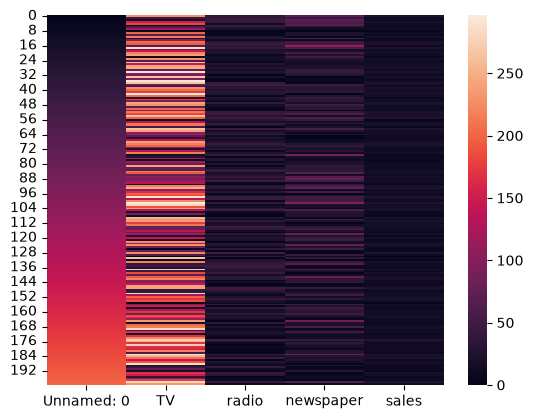

In [86]:
sns.heatmap(df)

In [102]:
no_TV= df.drop(columns=['Unnamed: 0'])

<Axes: >

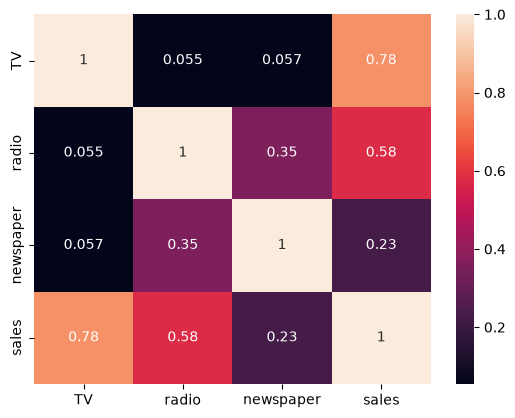

In [104]:
sns.heatmap(no_TV.corr(numeric_only=True), annot=True)

<Axes: xlabel='TV', ylabel='radio'>

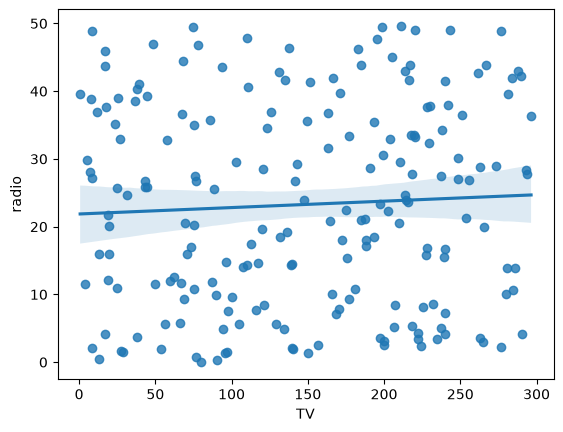

In [106]:
sns.regplot(data=df, x='TV', y='radio')

<Axes: xlabel='TV', ylabel='newspaper'>

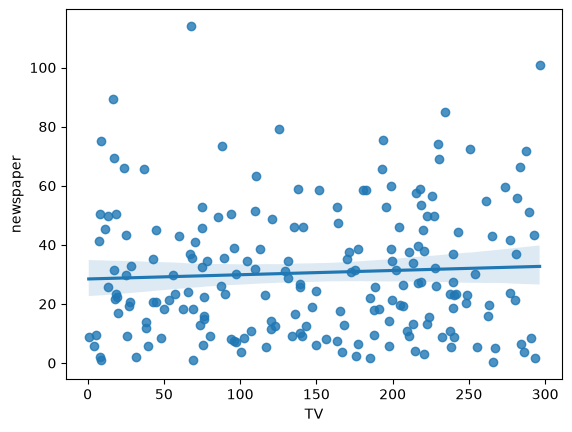

In [108]:
sns.regplot(data=df, x='TV', y='newspaper')

In [131]:
q1 = df['newspaper'].quantile(0.25)
q3 = df['newspaper'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df['newspaper'] <= lower_bound) |
    (df['newspaper'] >= upper_bound)
]

outliers

,Unnamed: 0,TV,radio,newspaper,sales
16,17,67.8,36.6,114.0,12.5
101,102,296.4,36.3,100.9,23.8


In [132]:
df_no_outliers = df[
    (df['newspaper'] >= lower_bound) &
    (df['newspaper'] <= upper_bound)
]

df_no_outliers['newspaper'].corr(df_no_outliers['sales'])

0.21955467558031128

In [134]:
df['newspaper'].corr(df['sales'])

0.22829902637616528

In [133]:
df_no_outliers

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
